# Tarea 2

## DCCoches Robados

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import parametros as pm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler



## *Parte 3.3.1 - Análisis de Datos*

### 1.

Cargamos los datos en el dataframe.

In [2]:
df_coches = pd.read_csv(pm.BD_COCHES)

Calculamos la cantidad de datos que hay en el dataframe, además de ver que atributos posee y de que tipo son cada uno.

In [3]:
len(df_coches)

7133

Podemos observar que el dataframe posee en total 7133 datos

In [4]:
df_coches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_prose                          7133 non-null   float64
 1   sin_patente                       7133 non-null   object 
 2   sin_fecha_siniestro               7133 non-null   object 
 3   ase_abreviatura                   7133 non-null   object 
 4   obs_ult_estado                    292 non-null    object 
 5   sin_siniestro                     7133 non-null   float64
 6   sin_fecha_denuncia                7133 non-null   object 
 7   lug_desc                          7133 non-null   object 
 8   pro_descripcion_provincia         7133 non-null   object 
 9   reg_descripcion_comuna            7133 non-null   object 
 10  sin_hora_siniestro                7133 non-null   object 
 11  esp_desc                          7133 non-null   object 
 12  sin_ch

Existen 28 atributos, de los cuales 4 son de tipo numérico, (`id_prose`, `sin_siniestro`, `sin_valor_comercial_veh`, `sin_ano_vechiculo`) 24 son de tipo object. Pero de esos 24 atributos de tipo object, poseemos fechas que pueden ser convertidas a hora y fecha `sin_fecha_siniestro` y `sin_fecha_denuncia`, `sin_hora_siniestro` y `sin_hora_denuncia`, `sin_fecha_parte`. Luego poseemos varios atributos que pueden ser convertidos a booleanos, como `sin_activo`, `encontradootravia` `sin_depositivos_vehiculo`, `sin_ind_caso_raro`, `sin_concurrencia`, `sin_check_registro_civil` y los demas datos son de tipo string que generalmente representan descripciones o identificadores.

Nuesta variable objetivo es `esp_desc` que representa el estado de busqueda del vehiculo, utilizando count veremos que estados hay. Existen dos estados de busqueda, `SEBV ENCONTRO` Y `SEBV BUSCA`, siendo el primer estado el mas frecuente con 4269 datos, mientras que el segundo estado tiene 2864 datos. Esto nos muestra que en la mayoria de los casos se encontro el vehiculo robado.

In [5]:
df_coches["esp_desc"].value_counts()

esp_desc
SEBV ENCONTRO     4269
SEBV BUSCA        2864
Name: count, dtype: int64

# 2.


Podemos obsservar que hay más vehiculos que se encontraron que los que se siguen buscando, que en parte, es bueno. Aun así, hay una gran cantidad de vehiculos que se siguen buscando y no han sido recuperados.

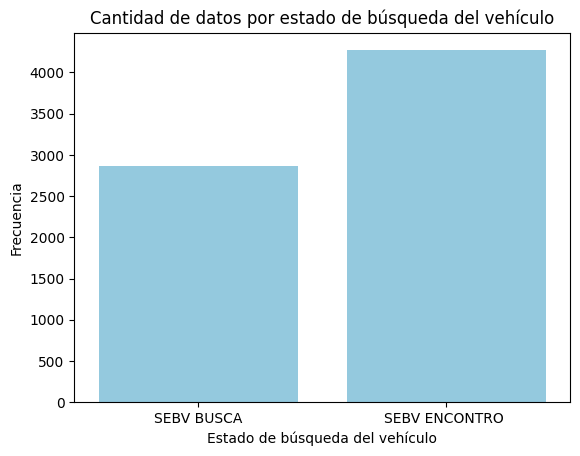

In [6]:
sns.countplot(x = "esp_desc", data = df_coches, color="skyblue")
plt.title("Cantidad de datos por estado de búsqueda del vehículo")
plt.ylabel("Frecuencia")
plt.xlabel("Estado de búsqueda del vehículo")   
plt.show()

Analicemos la variable de `mar_desc` que representa la marca del vehiculo. Se puede observar que se tiene información de 82 marcas distintas, siendo la marca `HYUNDAI` la más frecuente, seguida por `TOYOTA` y `CHEVROLET`. Esto nos muestra que estas tres marcas son las más robadas, o al menos las que más se reportan como robadas.

In [7]:
df_coches["mar_desc"].value_counts()

mar_desc
HYUNDAI       1619
TOYOTA         860
CHEVROLET      759
KIA MOTORS     653
NISSAN         573
              ... 
KENWORTH         1
SKODA            1
MAN              1
ZX               1
MG               1
Name: count, Length: 82, dtype: int64

Filtraremos las 10 más frecuentes para visualizarlo mejor.

In [8]:

for marca in df_coches["mar_desc"].value_counts().head(10).index:
    print(f"{marca}: {df_coches["mar_desc"].value_counts()[marca]}")


HYUNDAI: 1619
TOYOTA: 860
CHEVROLET: 759
KIA MOTORS: 653
NISSAN: 573
SUZUKI: 354
SUBARU: 228
MITSUBISHI: 184
SAMSUNG: 172
FORD: 165


Al tener tantas marcas, dejaremos solo las 5 más frecuentes y representaremos graficamente las demas en conjunto como "otras". (pandas, s.f.) (GeeksforGeeks, 2025)
El metodo crosstab nos permite crear una tabla con la frecuencia de las combinaciones de las variables `mar_desc` y `esp_desc`, luego con el metodo plot podemos graficar esta tabla. Para graficar solo las 5 marcas mas frecuentes, utilizamos el metodo where para filtrar solo estas marcas, y el resto lo representamos como "otras".

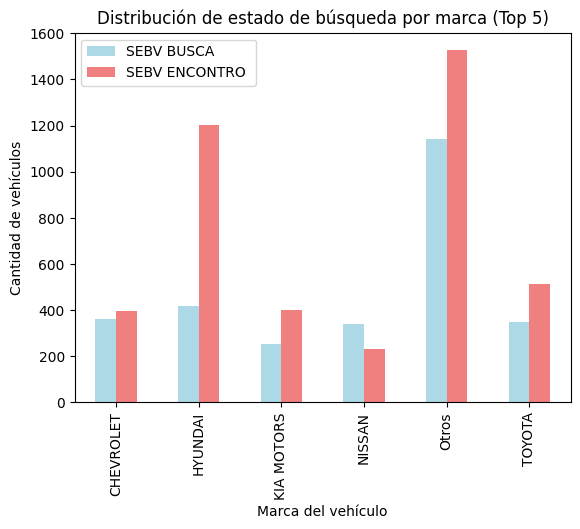

In [9]:
marcas_top5 = df_coches["mar_desc"].value_counts().head(5).index

tabla = pd.crosstab(
    df_coches["mar_desc"].where(df_coches["mar_desc"].isin(marcas_top5), "Otros"),
    df_coches["esp_desc"]
)
tabla.plot(kind="bar", stacked=False, color=["lightblue", "lightcoral"], label='Estado de búsqueda')
plt.title("Distribución de estado de búsqueda por marca (Top 5)")
plt.xlabel("Marca del vehículo")
plt.ylabel("Cantidad de vehículos")
plt.legend()
plt.show()

Podemos comprobar utilizando count para ver si el grafico es correcto. Se puede observar que en general, la mayoria de las marcas siguen la misma tendencia, es decir, que se encontraron mas vehiculos que los que se siguen buscando, pero por ejemplo `nissan` es una marca que se sigue buscando más que la cantidad de vehiculos encontrados.

In [10]:
df_coches[(df_coches["mar_desc"] == "HYUNDAI") & (df_coches["esp_desc"] == "SEBV BUSCA")]["mar_desc"].count()


np.int64(418)

Seguido de lo anterior, veremos las marcas que se siguen buscando más que las que se encontraron, para esto, filtraremos el dataframe por el estado de busqueda `SEBV BUSCA` y luego veremos la cantidad de cada marca en este estado.

In [11]:
tabla_total = pd.crosstab(
    df_coches["mar_desc"],
    df_coches["esp_desc"]
)
print(tabla_total)

esp_desc         SEBV BUSCA  SEBV ENCONTRO 
mar_desc                                   
AGRALE                    0               2
ALFA ROMEO                1               2
AMERICAN MOTORS           1               0
AUDI                     15              50
B.M.W.                   31              75
...                     ...             ...
WABASH                    1               0
YAMAHA                    4               1
YUE JIN                   1               1
ZOTYE                     0               1
ZX                        0               1

[82 rows x 2 columns]


In [12]:
tabla_filtrada = tabla_total[tabla_total["SEBV BUSCA"] > tabla_total["SEBV ENCONTRO "]]
print(tabla_filtrada)
len(tabla_filtrada)

esp_desc         SEBV BUSCA  SEBV ENCONTRO 
mar_desc                                   
AMERICAN MOTORS           1               0
CHANGAN                   2               1
DONGFENG                  3               2
DUCATTI                   1               0
FERRARI                   1               0
FLORES                    1               0
FOTON                     1               0
FREIGHTLINER             14              13
GEELY                     4               2
GOREN                     2               0
GREAT DANE                2               1
GUERRA                    1               0
HARLEY                    1               0
HINO                     15              10
INTERNATIONAL            10               3
IVECO                     7               2
KAWASAKI                  3               2
KIA                       1               0
MITSUBISHI              115              69
NISSAN                  341             232
OPEL                      5     

30

Se puede observar que existen 30 marcas que se siguen buscando más que las que se encontraron, siendo `NISSAN` la marca más buscada, seguida por `MITSUBISHI` y `SSANGYONG`. Esto nos muestra que estas marcas son las que más se siguen buscando, lo que puede indicar que son las marcas más robadas o las que más se reportan como robadas y no han sido recuperadas.

Ahora analizaremos la variable `sin_ano_vechiculo` que representa el año del vehiculo. 

In [13]:
df_coches["sin_ano_vechiculo"].value_counts()


sin_ano_vechiculo
2011.0    1339
2010.0     887
2012.0     887
2008.0     684
2013.0     611
2009.0     532
2007.0     463
2014.0     425
2006.0     346
2015.0     240
2005.0     175
2004.0     111
2016.0     104
2003.0      53
2001.0      52
2002.0      45
2000.0      40
1999.0      27
1997.0      27
1998.0      26
1996.0      17
1995.0      12
2017.0       9
1994.0       9
1992.0       4
1993.0       3
1990.0       1
1988.0       1
1986.0       1
1991.0       1
1989.0       1
Name: count, dtype: int64

In [14]:
df_coches["sin_ano_vechiculo"].nunique()

31

Podemos observar que existen 31 años diferentes, siendo los vehiculos del año 2011 más frecuentados. Nuevamente haremos la tabla de frecuencias cruzadas entre el estado y el año del vehiculo.

In [15]:
tabla_año = pd.crosstab(
    df_coches["sin_ano_vechiculo"],
    df_coches["esp_desc"]
)
print(tabla_año)

esp_desc           SEBV BUSCA  SEBV ENCONTRO 
sin_ano_vechiculo                            
1986.0                      1               0
1988.0                      1               0
1989.0                      1               0
1990.0                      1               0
1991.0                      1               0
1992.0                      1               3
1993.0                      3               0
1994.0                      5               4
1995.0                      4               8
1996.0                      7              10
1997.0                     16              11
1998.0                     16              10
1999.0                     13              14
2000.0                     20              20
2001.0                     25              27
2002.0                     21              24
2003.0                     14              39
2004.0                     54              57
2005.0                     71             104
2006.0                    136     

Tenemos el mismo problema que con las marcas, hay muchos años diferente, pero aprovecharemos la naturaleza continua de esta variable para graficarla como una linea ocupando el mismo metodo que con las marcas, pero cambiando el parametro kind a "line". Podemos observar que en general, la mayoria de los años siguen la misma tendencia, es decir, que se encontraron mas vehiculos que los que se siguen buscando.

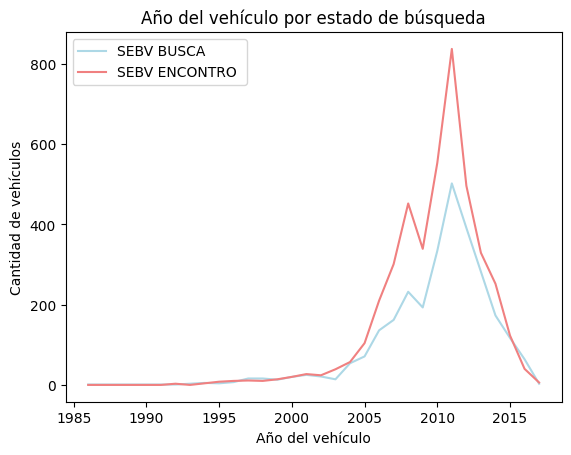

In [16]:
tabla_año.plot(kind="line", stacked=False, color=["lightblue", "lightcoral"], label='Estado de búsqueda')
plt.title("Año del vehículo por estado de búsqueda")
plt.xlabel("Año del vehículo")
plt.ylabel("Cantidad de vehículos")
plt.legend()
plt.show()

Otra grafico util es un grafico de cajas, que nos permite ver la distribucion de los años de los vehiculos encontrados y los que se siguen buscando. 

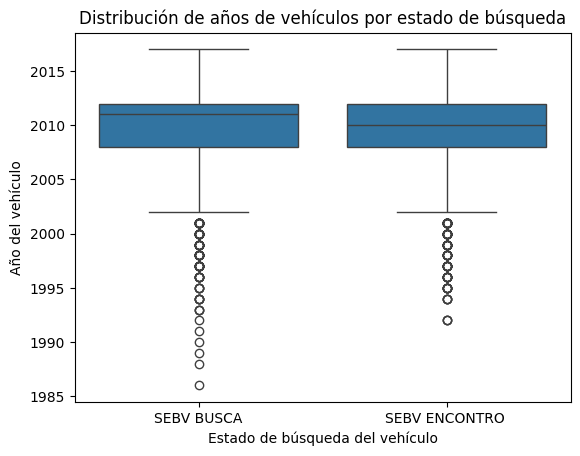

In [17]:
sns.boxplot(x="esp_desc", y="sin_ano_vechiculo", data=df_coches)
plt.title("Distribución de años de vehículos por estado de búsqueda")
plt.xlabel("Estado de búsqueda del vehículo")
plt.ylabel("Año del vehículo")
plt.show()


Se puede observar a partir de estos graficos algunas cosas. En primer lugar que la mayoria de los vehiculos robados son del siglo XXI, pero se puede observar que vehiculos más antiguos, son más dificiles de recuperar y que los vehiculos nuevos, aunque son robados con mayor frecuencia, son más faciles de recuperar.

Otra variable interesante de analizar seria el `sin_dispostivos_vehiculo` Como es una variable binaria que representa si el vehiculo tiene algun tipo dipositivo de seguridad. 

In [18]:
df_coches["sin_dispositivos_vehiculo"].value_counts()

sin_dispositivos_vehiculo
N    6993
S     140
Name: count, dtype: int64

In [19]:
tabla_dispositivos = pd.crosstab(
    df_coches["sin_dispositivos_vehiculo"],
    df_coches["esp_desc"]
)
print(tabla_dispositivos)

esp_desc                   SEBV BUSCA  SEBV ENCONTRO 
sin_dispositivos_vehiculo                            
N                                2765            4228
S                                  99              41


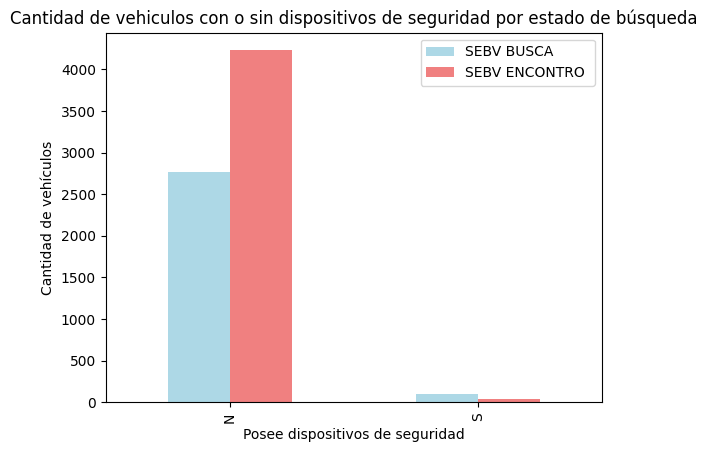

In [20]:
tabla_dispositivos.plot(kind="bar", stacked=False, color=["lightblue", "lightcoral"], label='Estado de búsqueda')
plt.title("Cantidad de vehiculos con o sin dispositivos de seguridad por estado de búsqueda")
plt.xlabel("Posee dispositivos de seguridad")
plt.ylabel("Cantidad de vehículos")
plt.legend()
plt.show()

Se puede observar que es totalmente contraitutivo, ya que la mayoria de los vehiculos robados no poseen dispositivos de seguridad, pero a su vez, la mayoria de los vehiculos encontrados tampoco poseen dispositivos de seguridad. Esto nos muestra que la presencia o ausencia de dispositivos de seguridad no parece tener un impacto significativo en la recuperación de los vehiculos robados.

Analicemos las fechas, en general no puede servir tanto, pero podria ser util analizar los dias que transcurrieron entre la fecha de denuncia y la fecha de siniestro, para esto, convertimos las fechas a formato datetime y luego calculamos la diferencia entre estas dos fechas.

In [21]:
nuevo_pd_coche = df_coches.copy()

nuevo_pd_coche["sin_fecha_denuncia"] = pd.to_datetime(nuevo_pd_coche["sin_fecha_denuncia"], dayfirst=True)

nuevo_pd_coche["sin_fecha_siniestro"] = pd.to_datetime(nuevo_pd_coche["sin_fecha_siniestro"], dayfirst=True, errors="coerce")

nuevo_pd_coche["dias_entre_denuncia_siniestro"] = (nuevo_pd_coche["sin_fecha_denuncia"] - nuevo_pd_coche["sin_fecha_siniestro"]).dt.days

print(nuevo_pd_coche[["sin_fecha_denuncia", "sin_fecha_siniestro", "dias_entre_denuncia_siniestro"]].head())




  sin_fecha_denuncia sin_fecha_siniestro  dias_entre_denuncia_siniestro
0         2015-11-19          2015-11-17                              2
1         2016-04-19          2016-04-15                              4
2         2013-10-08          2013-10-05                              3
3         2016-03-04          2016-03-03                              1
4         2012-09-03          2012-09-03                              0


In [22]:
nuevo_pd_coche["dias_entre_denuncia_siniestro"].value_counts()

dias_entre_denuncia_siniestro
 1      2618
 0      2289
 2       820
 3       437
 4       252
        ... 
 171       1
 83        1
 40        1
-50        1
 79        1
Name: count, Length: 66, dtype: int64

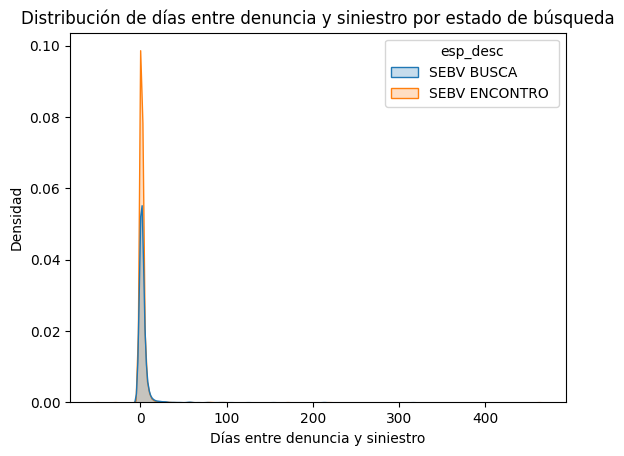

In [23]:
sns.kdeplot(data=nuevo_pd_coche, x="dias_entre_denuncia_siniestro", hue="esp_desc", fill=True)
plt.title("Distribución de días entre denuncia y siniestro por estado de búsqueda")
plt.xlabel("Días entre denuncia y siniestro")
plt.ylabel("Densidad")
plt.show()

Se puede observar que casi todos los vehiculos fueron denunciados el mismo dia del siniestro, y en general, no nos entrega mucha información relevante.

## *Parte 3.3.2 - Procesamiento de datos*

En primer lugar analizaremos las columnas y si es necesario eliminar alguna columna que no aporte información relevante para el análisis. Haremos una copia del dataframe y limpiarla.


In [24]:
df_coche_limpio = df_coches.copy()

#### 1. `id_prose, sin_siniestro, sin_patente`

Estas columnas representan identificadores unicos para cada registro por lo que no aportan información relevante para el análisis, por lo que se pueden eliminar.

In [25]:
df_coche_limpio.drop(columns=["id_prose", "sin_siniestro", "sin_patente"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sin_fecha_siniestro               7133 non-null   object 
 1   ase_abreviatura                   7133 non-null   object 
 2   obs_ult_estado                    292 non-null    object 
 3   sin_fecha_denuncia                7133 non-null   object 
 4   lug_desc                          7133 non-null   object 
 5   pro_descripcion_provincia         7133 non-null   object 
 6   reg_descripcion_comuna            7133 non-null   object 
 7   sin_hora_siniestro                7133 non-null   object 
 8   esp_desc                          7133 non-null   object 
 9   sin_check_registro_civil          7133 non-null   object 
 10  sin_concurrencia                  7133 non-null   object 
 11  sin_ind_caso_raro                 7133 non-null   object 
 12  tve_de

#### 2. `sin_relato`

Esta columna representa el relato, pero es una columna de texto variable, por lo que no aporta información relevante para el análisis, por lo que se puede eliminar


In [26]:
df_coche_limpio.drop(columns=["sin_relato"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sin_fecha_siniestro               7133 non-null   object 
 1   ase_abreviatura                   7133 non-null   object 
 2   obs_ult_estado                    292 non-null    object 
 3   sin_fecha_denuncia                7133 non-null   object 
 4   lug_desc                          7133 non-null   object 
 5   pro_descripcion_provincia         7133 non-null   object 
 6   reg_descripcion_comuna            7133 non-null   object 
 7   sin_hora_siniestro                7133 non-null   object 
 8   esp_desc                          7133 non-null   object 
 9   sin_check_registro_civil          7133 non-null   object 
 10  sin_concurrencia                  7133 non-null   object 
 11  sin_ind_caso_raro                 7133 non-null   object 
 12  tve_de

#### 3. `sin_fecha_siniestro, sin_fecha_denuncia, sin_fecha_parte`, `sin_hora_siniestro`

Estas columnas representan fechas, pero no aportan información relevante para el análisis por si solas, por lo que se pueden eliminar. Sin embargo, como se menciono anteriormente, se puede calcular la diferencia entre la fecha de denuncia y la fecha de siniestro para obtener una nueva columna que represente el tiempo transcurrido entre estos dos eventos, lo que podría ser útil para el análisis.

En otro caso, `sin_hora_siniestro` no aporta información relevante, ya que la hora del siniestro no parece tener un impacto significativo en la recuperación de los vehiculos robados, por lo que se puede eliminar.

In [27]:
df_coche_limpio["sin_fecha_denuncia"] = pd.to_datetime(df_coche_limpio["sin_fecha_denuncia"], dayfirst=True)

df_coche_limpio["sin_fecha_siniestro"] = pd.to_datetime(df_coche_limpio["sin_fecha_siniestro"], dayfirst=True, errors="coerce")

df_coche_limpio["dias_entre_denuncia_siniestro"] = (df_coche_limpio["sin_fecha_denuncia"] - df_coche_limpio["sin_fecha_siniestro"]).dt.days





In [28]:
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   sin_fecha_siniestro               7133 non-null   datetime64[ns]
 1   ase_abreviatura                   7133 non-null   object        
 2   obs_ult_estado                    292 non-null    object        
 3   sin_fecha_denuncia                7133 non-null   datetime64[ns]
 4   lug_desc                          7133 non-null   object        
 5   pro_descripcion_provincia         7133 non-null   object        
 6   reg_descripcion_comuna            7133 non-null   object        
 7   sin_hora_siniestro                7133 non-null   object        
 8   esp_desc                          7133 non-null   object        
 9   sin_check_registro_civil          7133 non-null   object        
 10  sin_concurrencia                  7133 non-null 

In [29]:
df_coche_limpio.drop(columns=["sin_fecha_denuncia", "sin_fecha_siniestro", "sin_hora_siniestro", "sin_fecha_parte"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ase_abreviatura                   7133 non-null   object 
 1   obs_ult_estado                    292 non-null    object 
 2   lug_desc                          7133 non-null   object 
 3   pro_descripcion_provincia         7133 non-null   object 
 4   reg_descripcion_comuna            7133 non-null   object 
 5   esp_desc                          7133 non-null   object 
 6   sin_check_registro_civil          7133 non-null   object 
 7   sin_concurrencia                  7133 non-null   object 
 8   sin_ind_caso_raro                 7133 non-null   object 
 9   tve_desc                          7133 non-null   object 
 10  mar_desc                          7133 non-null   object 
 11  sin_ano_vechiculo                 7133 non-null   float64
 12  cve_de

#### 4. `ase_abreviatura`

Esta columna representa la abreviatura de la asegurada, veremos si es util o no.

In [30]:
tabla_ase = pd.crosstab(
    df_coche_limpio["ase_abreviatura"],
    df_coche_limpio["esp_desc"],
    normalize="index"
)
print(tabla_ase)

esp_desc         SEBV BUSCA  SEBV ENCONTRO 
ase_abreviatura                            
AIG CHILE          0.691824        0.308176
BCI                0.397776        0.602224
CONSORCIO          0.238095        0.761905
LIBERTY            0.393819        0.606181
ZNT                0.466667        0.533333


Puede ser una variable interesante de mantener, además presenta pocas categorias. Utilizaremos one hot encoding para convertir esta variable en variables binarias.

In [31]:
df_coche_limpio = pd.get_dummies(df_coche_limpio, columns=["ase_abreviatura"])

df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   obs_ult_estado                    292 non-null    object 
 1   lug_desc                          7133 non-null   object 
 2   pro_descripcion_provincia         7133 non-null   object 
 3   reg_descripcion_comuna            7133 non-null   object 
 4   esp_desc                          7133 non-null   object 
 5   sin_check_registro_civil          7133 non-null   object 
 6   sin_concurrencia                  7133 non-null   object 
 7   sin_ind_caso_raro                 7133 non-null   object 
 8   tve_desc                          7133 non-null   object 
 9   mar_desc                          7133 non-null   object 
 10  sin_ano_vechiculo                 7133 non-null   float64
 11  cve_desc                          7133 non-null   object 
 12  sin_va

#### 5. `obs_ult_estado`

Por la cantidad de valores nulos, esta atributo no aporta información relevante para el análisis, por lo que se puede eliminar.

In [32]:
df_coche_limpio.drop(columns=["obs_ult_estado"], inplace=True)
df_coche_limpio.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   lug_desc                          7133 non-null   object 
 1   pro_descripcion_provincia         7133 non-null   object 
 2   reg_descripcion_comuna            7133 non-null   object 
 3   esp_desc                          7133 non-null   object 
 4   sin_check_registro_civil          7133 non-null   object 
 5   sin_concurrencia                  7133 non-null   object 
 6   sin_ind_caso_raro                 7133 non-null   object 
 7   tve_desc                          7133 non-null   object 
 8   mar_desc                          7133 non-null   object 
 9   sin_ano_vechiculo                 7133 non-null   float64
 10  cve_desc                          7133 non-null   object 
 11  sin_valor_comercial_veh           7133 non-null   float64
 12  sin_di

#### 6. `lug_desc`

Esta columna representa el lugar del siniestro, puede ser una variable interesante de mantener. Se puede observar que dependiendo de lugar, lso vehiculos tienden a encontrarse más o o no.

In [33]:
tabla_lug = pd.crosstab(
    df_coche_limpio["lug_desc"],
    df_coche_limpio["esp_desc"],
    normalize="index"
)
print(tabla_lug)

esp_desc          SEBV BUSCA  SEBV ENCONTRO 
lug_desc                                    
Calle               0.571885        0.428115
Centro Comercial    0.348066        0.651934
Colegio             0.500000        0.500000
Domicilio           0.400150        0.599850
Otra                0.393585        0.606415


In [34]:
df_coche_limpio = pd.get_dummies(df_coche_limpio, columns=["lug_desc"])

In [35]:
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pro_descripcion_provincia         7133 non-null   object 
 1   reg_descripcion_comuna            7133 non-null   object 
 2   esp_desc                          7133 non-null   object 
 3   sin_check_registro_civil          7133 non-null   object 
 4   sin_concurrencia                  7133 non-null   object 
 5   sin_ind_caso_raro                 7133 non-null   object 
 6   tve_desc                          7133 non-null   object 
 7   mar_desc                          7133 non-null   object 
 8   sin_ano_vechiculo                 7133 non-null   float64
 9   cve_desc                          7133 non-null   object 
 10  sin_valor_comercial_veh           7133 non-null   float64
 11  sin_dispositivos_vehiculo         7133 non-null   object 
 12  reg_de

#### 7. `reg_descripcion_region_asegurado`, `reg_descripcion_comuna_asegurado`, `reg_descripcion_region_conductor`, `pro_descripcion_provincia`, `pro_descripcion_comuna`, `sin_comiseria`


Son variables geofraficas que representan la region y comuna del asegurado y del conductor, y la provincia y comuna del siniestro. Estas variables tienen mucho ruido, por ejemplo hay comunas que aparecen muy pocas veces y otras muchas veces, por lo que puede causar ruido en el análisis, por lo que se pueden eliminar.

Comisaria hay demasiadas categorias, por lo que se puede eliminar.

In [36]:
print(pd.crosstab(df_coche_limpio['pro_descripcion_provincia'], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc                   SEBV BUSCA  SEBV ENCONTRO 
pro_descripcion_provincia                            
Antofagasta                  0.444444        0.555556
Biobío                       1.000000        0.000000
Cautín                       0.000000        1.000000
Chacabuco                    0.000000        1.000000
Concepción                   0.166667        0.833333
Copiapó                      0.000000        1.000000
Cordillera                   0.000000        1.000000
El Loa                       0.800000        0.200000
Elqui                        0.500000        0.500000
Iquique                      0.500000        0.500000
Llanquihue                   1.000000        0.000000
Maipo                        1.000000        0.000000
Melipilla                    1.000000        0.000000
Otra                         0.395246        0.604754
Santiago                     0.523810        0.476190
Valparaíso                   0.500000        0.500000


In [37]:
print(pd.crosstab(df_coche_limpio['sin_comisaria'], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc                SEBV BUSCA  SEBV ENCONTRO 
sin_comisaria                                     
.                            1.000           0.000
1 COM DE CALAMA              1.000           0.000
1 COM SAN PEDRO LA PAZ       0.000           1.000
1 COM. DE RANCAGUA           1.000           0.000
1 COMISARIA DE CALAMA        1.000           0.000
...                            ...             ...
Tenencia Vista Alegre        0.125           0.875
VITACURA                     1.000           0.000
VOMISARIA DE VITACURA        0.000           1.000
¿? Com. Ñuñoa                0.000           1.000
ÑUÑOA                        0.000           1.000

[885 rows x 2 columns]


In [38]:
df_coche_limpio.drop(columns=["reg_descripcion_region_asegurado", "reg_descripcion_comuna_asegurado", "reg_descripcion_region_conductor", "pro_descripcion_provincia", "reg_descripcion_comuna", "sin_comisaria"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   sin_check_registro_civil       7133 non-null   object 
 2   sin_concurrencia               7133 non-null   object 
 3   sin_ind_caso_raro              7133 non-null   object 
 4   tve_desc                       7133 non-null   object 
 5   mar_desc                       7133 non-null   object 
 6   sin_ano_vechiculo              7133 non-null   float64
 7   cve_desc                       7133 non-null   object 
 8   sin_valor_comercial_veh        7133 non-null   float64
 9   sin_dispositivos_vehiculo      7133 non-null   object 
 10  sin_activo                     7133 non-null   object 
 11  EncontradoOtraVia              7133 non-null   object 
 12  dias_entre_denuncia_siniestro  7133 non-null   i

#### 8. `sin_check_registro_civil`, `sin_concurrencia`, `sin_ind_caso_raro`


Son variables binarias que representan si el siniestro fue registrado en el registro civil, si hubo concurrencia de otros vehiculos y si el caso es raro. Estas variables pueden ser interesantes de mantener, ya que pueden tener un impacto en la recuperación de los vehiculos robados. analizaremos estas variables.

In [39]:
print(df_coche_limpio["sin_check_registro_civil"].value_counts())
print(pd.crosstab(df_coche_limpio["sin_check_registro_civil"], df_coche_limpio['esp_desc'], normalize='index'))

sin_check_registro_civil
S    7108
N      25
Name: count, dtype: int64
esp_desc                  SEBV BUSCA  SEBV ENCONTRO 
sin_check_registro_civil                            
N                           0.040000        0.960000
S                           0.402786        0.597214


In [40]:
print(df_coche_limpio["sin_concurrencia"].value_counts())
print(pd.crosstab(df_coche_limpio["sin_concurrencia"], df_coche_limpio['esp_desc'], normalize='index'))

sin_concurrencia
N    7111
S      22
Name: count, dtype: int64
esp_desc          SEBV BUSCA  SEBV ENCONTRO 
sin_concurrencia                            
N                   0.400928        0.599072
S                   0.590909        0.409091


In [41]:
print(df_coche_limpio["sin_ind_caso_raro"].value_counts())
print(pd.crosstab(df_coche_limpio["sin_ind_caso_raro"], df_coche_limpio['esp_desc'], normalize='index'))

sin_ind_caso_raro
N    7020
S     113
Name: count, dtype: int64
esp_desc           SEBV BUSCA  SEBV ENCONTRO 
sin_ind_caso_raro                            
N                    0.400000        0.600000
S                    0.495575        0.504425


Se puede observar que las variables estan muy desbalanceadas, y realemente pueden generar muchos ruido en el análisis, por lo que se pueden eliminar. 

In [42]:
df_coche_limpio.drop(columns=["sin_check_registro_civil", "sin_concurrencia", "sin_ind_caso_raro"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   object 
 2   mar_desc                       7133 non-null   object 
 3   sin_ano_vechiculo              7133 non-null   float64
 4   cve_desc                       7133 non-null   object 
 5   sin_valor_comercial_veh        7133 non-null   float64
 6   sin_dispositivos_vehiculo      7133 non-null   object 
 7   sin_activo                     7133 non-null   object 
 8   EncontradoOtraVia              7133 non-null   object 
 9   dias_entre_denuncia_siniestro  7133 non-null   int64  
 10  ase_abreviatura_AIG CHILE      7133 non-null   bool   
 11  ase_abreviatura_BCI            7133 non-null   bool   
 12  ase_abreviatura_CONSORCIO      7133 non-null   b

#### 9. `tve_desc` y `mar_desc`

Representa el tipo de vehiculo, analizaremos la distribucion y si existe alguna tendencia entre el tipo de vehiculo y el estado de busqueda. Puede ser util para el análisis mantenerlo, como son demasiadas categorias, haremos label encoding para convertir esta variable en una variable numerica.

Sin embargo las marcas las eliminaremos porque como vimos anteriormente, hay muchas marcas diferentes y no entrega demasiada informacion.

In [43]:
print(pd.crosstab(df_coche_limpio["tve_desc"], df_coche_limpio["esp_desc"], normalize='index'))
print(df_coche_limpio["tve_desc"].value_counts())

esp_desc                                            SEBV BUSCA  SEBV ENCONTRO 
tve_desc                                                                      
AUTOMOVIL                                             0.347691        0.652309
BUSES Y TAXIBUSES                                     0.800000        0.200000
Bicicleta                                             1.000000        0.000000
CAMIONES                                              0.558642        0.441358
CAMIONETA                                             0.636732        0.363268
CARROS DE ARRASTRE                                    0.916667        0.083333
ESTANQUES METALICOS DE ACERO INOXIDABLE (SIN CH...    0.500000        0.500000
FURGON                                                0.456067        0.543933
MINIBUS                                               0.605263        0.394737
MOTOCICLETAS                                          0.750000        0.250000
Otro                                                

In [44]:
print(pd.crosstab(df_coche_limpio["mar_desc"], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc         SEBV BUSCA  SEBV ENCONTRO 
mar_desc                                   
AGRALE             0.000000        1.000000
ALFA ROMEO         0.333333        0.666667
AMERICAN MOTORS    1.000000        0.000000
AUDI               0.230769        0.769231
B.M.W.             0.292453        0.707547
...                     ...             ...
WABASH             1.000000        0.000000
YAMAHA             0.800000        0.200000
YUE JIN            0.500000        0.500000
ZOTYE              0.000000        1.000000
ZX                 0.000000        1.000000

[82 rows x 2 columns]


In [45]:
label = LabelEncoder()
df_coche_limpio["tve_desc"] = label.fit_transform(df_coche_limpio["tve_desc"])
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   object 
 3   sin_ano_vechiculo              7133 non-null   float64
 4   cve_desc                       7133 non-null   object 
 5   sin_valor_comercial_veh        7133 non-null   float64
 6   sin_dispositivos_vehiculo      7133 non-null   object 
 7   sin_activo                     7133 non-null   object 
 8   EncontradoOtraVia              7133 non-null   object 
 9   dias_entre_denuncia_siniestro  7133 non-null   int64  
 10  ase_abreviatura_AIG CHILE      7133 non-null   bool   
 11  ase_abreviatura_BCI            7133 non-null   bool   
 12  ase_abreviatura_CONSORCIO      7133 non-null   b

In [46]:
df_coche_limpio["mar_desc"] = label.fit_transform(df_coche_limpio["mar_desc"])
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   int64  
 3   sin_ano_vechiculo              7133 non-null   float64
 4   cve_desc                       7133 non-null   object 
 5   sin_valor_comercial_veh        7133 non-null   float64
 6   sin_dispositivos_vehiculo      7133 non-null   object 
 7   sin_activo                     7133 non-null   object 
 8   EncontradoOtraVia              7133 non-null   object 
 9   dias_entre_denuncia_siniestro  7133 non-null   int64  
 10  ase_abreviatura_AIG CHILE      7133 non-null   bool   
 11  ase_abreviatura_BCI            7133 non-null   bool   
 12  ase_abreviatura_CONSORCIO      7133 non-null   b

#### 10. `sin_ano_vechiculo`

Como vimos habia una ligera tendencia que entre más antiguo es el vehiculo, más dificil es de recuperar, por lo que puede ser interesante de mantener esta variable para el análisis. Es una variable numerica, por lo que no es necesario hacer ninguna transformación.

#### 11. `cve_desc`

Variable que representa el color del vehiculo. Realmente no aporta mucha información relevante para el anáisis, por varias razones. En primer lugar, hay muchos colores diferentes y el color del vehiculo no parece tener un impacto significativo en la recuperación de los vehiculos robados, por lo que se puede eliminar. 

In [47]:
print(df_coche_limpio['cve_desc'].value_counts())
print(pd.crosstab(df_coche_limpio['cve_desc'], df_coche_limpio['esp_desc'], normalize='index'))

cve_desc
Blanco      2167
Plateado    1494
Gris        1244
Rojo         806
Negro        455
Azul         424
Beige        165
Verde        156
Celeste       63
Dorado        45
Otro          43
Naranja       26
Amarillo      22
Café          22
Rosado         1
Name: count, dtype: int64
esp_desc  SEBV BUSCA  SEBV ENCONTRO 
cve_desc                            
Amarillo    0.681818        0.318182
Azul        0.356132        0.643868
Beige       0.424242        0.575758
Blanco      0.437471        0.562529
Café        0.500000        0.500000
Celeste     0.285714        0.714286
Dorado      0.244444        0.755556
Gris        0.368167        0.631833
Naranja     0.500000        0.500000
Negro       0.353846        0.646154
Otro        0.418605        0.581395
Plateado    0.332664        0.667336
Rojo        0.544665        0.455335
Rosado      0.000000        1.000000
Verde       0.346154        0.653846


In [48]:
df_coche_limpio.drop(columns=["cve_desc"], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   int64  
 3   sin_ano_vechiculo              7133 non-null   float64
 4   sin_valor_comercial_veh        7133 non-null   float64
 5   sin_dispositivos_vehiculo      7133 non-null   object 
 6   sin_activo                     7133 non-null   object 
 7   EncontradoOtraVia              7133 non-null   object 
 8   dias_entre_denuncia_siniestro  7133 non-null   int64  
 9   ase_abreviatura_AIG CHILE      7133 non-null   bool   
 10  ase_abreviatura_BCI            7133 non-null   bool   
 11  ase_abreviatura_CONSORCIO      7133 non-null   bool   
 12  ase_abreviatura_LIBERTY        7133 non-null   b

#### 12. `sin_valor_comercial_veh ` 

Esta variable es numerica y representa el valor comercial del vehiculo, seria util mantener esta variable para el análisis, ya que el valor comercial del vehiculo puede tener un impacto en la recuperación de los vehiculos robados, ya que vehiculos de mayor valor comercial pueden ser más atractivos para los ladrones y pueden ser más difíciles de recuperar, por lo que se puede mantener esta variable para el análisis.

#### 13. `sin_dispostivos_vehiculo`

Variable binaria que representa si el vehiculo tiene algun tipo dipositivo de seguridad. Esta variable puede ser interesante de mantener, ya que la presencia o ausencia de dispositivos de seguridad puede tener un impacto en la recuperación de los vehiculos robados, ya que los vehiculos con dispositivos de seguridad (Aunque hayamos visto que no parece tener un impacto significativo y que cumple totalmente un rol inverso de lo pensado).

In [49]:
print(pd.crosstab(df_coche_limpio["sin_dispositivos_vehiculo"], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc                   SEBV BUSCA  SEBV ENCONTRO 
sin_dispositivos_vehiculo                            
N                            0.395395        0.604605
S                            0.707143        0.292857


Dos categorias, haremos one hot encoding para convertir esta variable en variables binarias.

In [50]:
df_coche_limpio = pd.get_dummies(df_coche_limpio, columns=["sin_dispositivos_vehiculo"])

In [51]:
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   int64  
 3   sin_ano_vechiculo              7133 non-null   float64
 4   sin_valor_comercial_veh        7133 non-null   float64
 5   sin_activo                     7133 non-null   object 
 6   EncontradoOtraVia              7133 non-null   object 
 7   dias_entre_denuncia_siniestro  7133 non-null   int64  
 8   ase_abreviatura_AIG CHILE      7133 non-null   bool   
 9   ase_abreviatura_BCI            7133 non-null   bool   
 10  ase_abreviatura_CONSORCIO      7133 non-null   bool   
 11  ase_abreviatura_LIBERTY        7133 non-null   bool   
 12  ase_abreviatura_ZNT            7133 non-null   b

#### 14. `sin_activo`

Esta variable se debe eliminar porque todos los vehiculos robados estan activos, por lo que no aporta información relevante para el análisis.

In [52]:
print(pd.crosstab(df_coche_limpio["sin_activo"], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc    SEBV BUSCA  SEBV ENCONTRO 
sin_activo                            
S             0.401514        0.598486


In [53]:
df_coche_limpio.drop(columns=['sin_activo'], inplace=True)
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   int64  
 3   sin_ano_vechiculo              7133 non-null   float64
 4   sin_valor_comercial_veh        7133 non-null   float64
 5   EncontradoOtraVia              7133 non-null   object 
 6   dias_entre_denuncia_siniestro  7133 non-null   int64  
 7   ase_abreviatura_AIG CHILE      7133 non-null   bool   
 8   ase_abreviatura_BCI            7133 non-null   bool   
 9   ase_abreviatura_CONSORCIO      7133 non-null   bool   
 10  ase_abreviatura_LIBERTY        7133 non-null   bool   
 11  ase_abreviatura_ZNT            7133 non-null   bool   
 12  lug_desc_Calle                 7133 non-null   b

#### 15. `EncontradoOtraVia`


Variable que representa si el vehiculo fue encontrado por otra via, esta variable puede ser interesante de mantener, veremos que tal influye. Igualmente es una variabla `extraña` porque no se sabe exactamente que significa "encontrado por otra via", pero puede ser una variable interesante de mantener, ya que puede tener un impacto en la recuperación de los vehiculos robados, por lo que se puede mantener esta variable para el análisis. Asi que se mantendra y se hara one hot encoding para convertir esta variable en variables binarias. 

Si suponemos que esta variable representa si el vehiculo fue encontrado por otra via que no sea la policia, entonces esta variable puede ser interesante de mantener, ya que puede tener un impacto en la recuperación de los vehiculos robados, el problema seria que si esta variable estuviera "prediciendo" entonces seria un caso de data leakage, pero esto no parece ser el caso, ya que aunque los vehiculos encontrados por otra via tienen una mayor probabilidad de ser encontrados, no es algo tan determinante como para que esta variable este prediciendo el estado de busqueda del vehiculo, por lo que se puede mantener esta variable para el análisis. Asi que se mantendra y se hara one hot encoding para convertir esta variable en variables binarias.

In [54]:
print(pd.crosstab(df_coche_limpio["EncontradoOtraVia"], df_coche_limpio['esp_desc'], normalize='index'))

esp_desc           SEBV BUSCA  SEBV ENCONTRO 
EncontradoOtraVia                            
NO                   0.584942        0.415058
SI                   0.206138        0.793862


In [55]:
print(df_coche_limpio["EncontradoOtraVia"].value_counts())

EncontradoOtraVia
NO    3679
SI    3454
Name: count, dtype: int64


Se puede observar que la los vehiculos encontrados por otra via, tienen una mayor probabilidad de ser encontrados que los que no fueron encontrados por otra via, lo que puede indicar que esta variable tiene un impacto significativo en la recuperación de los vehiculos robados, por lo que se puede mantener esta variable para el análisis. Asi que se mantendra y se hara one hot encoding para convertir esta variable en variables binarias.

In [56]:
df_coche_limpio = pd.get_dummies(df_coche_limpio, columns=["EncontradoOtraVia"])
df_coche_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7133 entries, 0 to 7132
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   esp_desc                       7133 non-null   object 
 1   tve_desc                       7133 non-null   int64  
 2   mar_desc                       7133 non-null   int64  
 3   sin_ano_vechiculo              7133 non-null   float64
 4   sin_valor_comercial_veh        7133 non-null   float64
 5   dias_entre_denuncia_siniestro  7133 non-null   int64  
 6   ase_abreviatura_AIG CHILE      7133 non-null   bool   
 7   ase_abreviatura_BCI            7133 non-null   bool   
 8   ase_abreviatura_CONSORCIO      7133 non-null   bool   
 9   ase_abreviatura_LIBERTY        7133 non-null   bool   
 10  ase_abreviatura_ZNT            7133 non-null   bool   
 11  lug_desc_Calle                 7133 non-null   bool   
 12  lug_desc_Centro Comercial      7133 non-null   b

## Parte 3.3.3 - Division de datos

Dividimos los datos en 70% para entrenamiento, 15% para validación y 15% para test. Haremos esto para poder evaluar y ajustar correctamente los modelos que entrenamos.

In [57]:
features = list(df_coche_limpio.columns.drop("esp_desc"))

target = "esp_desc"

In [58]:
x = df_coche_limpio[features]
y = df_coche_limpio[target]

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [60]:
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

In [61]:
x_train.head()

,tve_desc,mar_desc,sin_ano_vechiculo,sin_valor_comercial_veh,dias_entre_denuncia_siniestro,ase_abreviatura_AIG CHILE,ase_abreviatura_BCI,ase_abreviatura_CONSORCIO,ase_abreviatura_LIBERTY,ase_abreviatura_ZNT,lug_desc_Calle,lug_desc_Centro Comercial,lug_desc_Colegio,lug_desc_Domicilio,lug_desc_Otra,sin_dispositivos_vehiculo_N,sin_dispositivos_vehiculo_S,EncontradoOtraVia_NO,EncontradoOtraVia_SI
1351,7,32,2011.0,8159435.0,1,False,False,False,True,False,False,False,False,False,True,True,False,True,False
3929,4,67,2010.0,7625372.0,6,False,False,False,True,False,False,False,False,False,True,True,False,False,True
5229,13,32,2008.0,19770866.0,0,False,False,False,True,False,False,False,False,False,True,True,False,False,True
6118,13,32,2010.0,23922135.0,2,False,False,False,True,False,False,False,False,False,True,True,False,False,True
1973,7,58,2008.0,5279466.0,1,False,False,False,True,False,False,False,False,False,True,True,False,False,True


## Parte 3.3.4 y 3.3.5 - Entrenamiento de modelos y analisis de resultados

#### 1. Arbol de decision

Este contiene el parametro `max_depth` que representa la profundidad máxima del árbol. Buscaremos el mejor valor para este parametro utilizando grindsearch que veremos todas las combinaciones posibles de los parametros `max_depth`, `min_samples_split`, `min_samples_leaf` y `criterion` para encontrar el mejor modelo.

Lo que hace cada hiperparametro es lo siguiente:
- `max_depth`: Este hiperparámetro controla la profundidad máxima del árbol. Más profundidad, capta más complejidad con riesgo de sobreajuste, mientras que menos profundidad puede resultar en un modelo más simple pero con riesgo de subajuste.
- `min_samples_split`: Este hiperparámetro controla el número mínimo de muestras necesarias para dividir un nodo. 
- `min_samples_leaf`: Este hiperparámetro controla el número mínimo de muestras necesarias para estar en un nodo hoja.
- `criterion`: Este hiperparámetro controla la función de evaluación utilizada para medir la calidad. Ejemplo "gini" o "entropy".

(scikit-learn, s.f.)

In [84]:
modelo = DecisionTreeClassifier(random_state=42)

#Se ocuparan varios hiperparametros de la documentacion de DecisionTreeClassifier.
mejor_modelo = GridSearchCV(modelo, {"max_depth": [3, 5, 7, 10, 15, 20, None], "min_samples_split": [5, 10, 15, 20], "min_samples_leaf": [1, 2, 5, 10], "criterion": ["gini", "entropy"]}, cv=5, scoring="accuracy", n_jobs=-1)

mejor_modelo.fit(x_train, y_train)

print("Mejores hiperparámetros:", mejor_modelo.best_params_)



Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [101]:
y_pred_val = mejor_modelo.predict(x_val)

pd.DataFrame({"y_val": y_val, "y_pred_val": y_pred_val})

,y_val,y_pred_val
4420,SEBV ENCONTRO,SEBV ENCONTRO
3450,SEBV ENCONTRO,SEBV BUSCA
2488,SEBV BUSCA,SEBV BUSCA
1768,SEBV BUSCA,SEBV BUSCA
1886,SEBV BUSCA,SEBV BUSCA
...,...,...
3383,SEBV ENCONTRO,SEBV BUSCA
6732,SEBV ENCONTRO,SEBV ENCONTRO
1862,SEBV BUSCA,SEBV ENCONTRO
2687,SEBV BUSCA,SEBV BUSCA


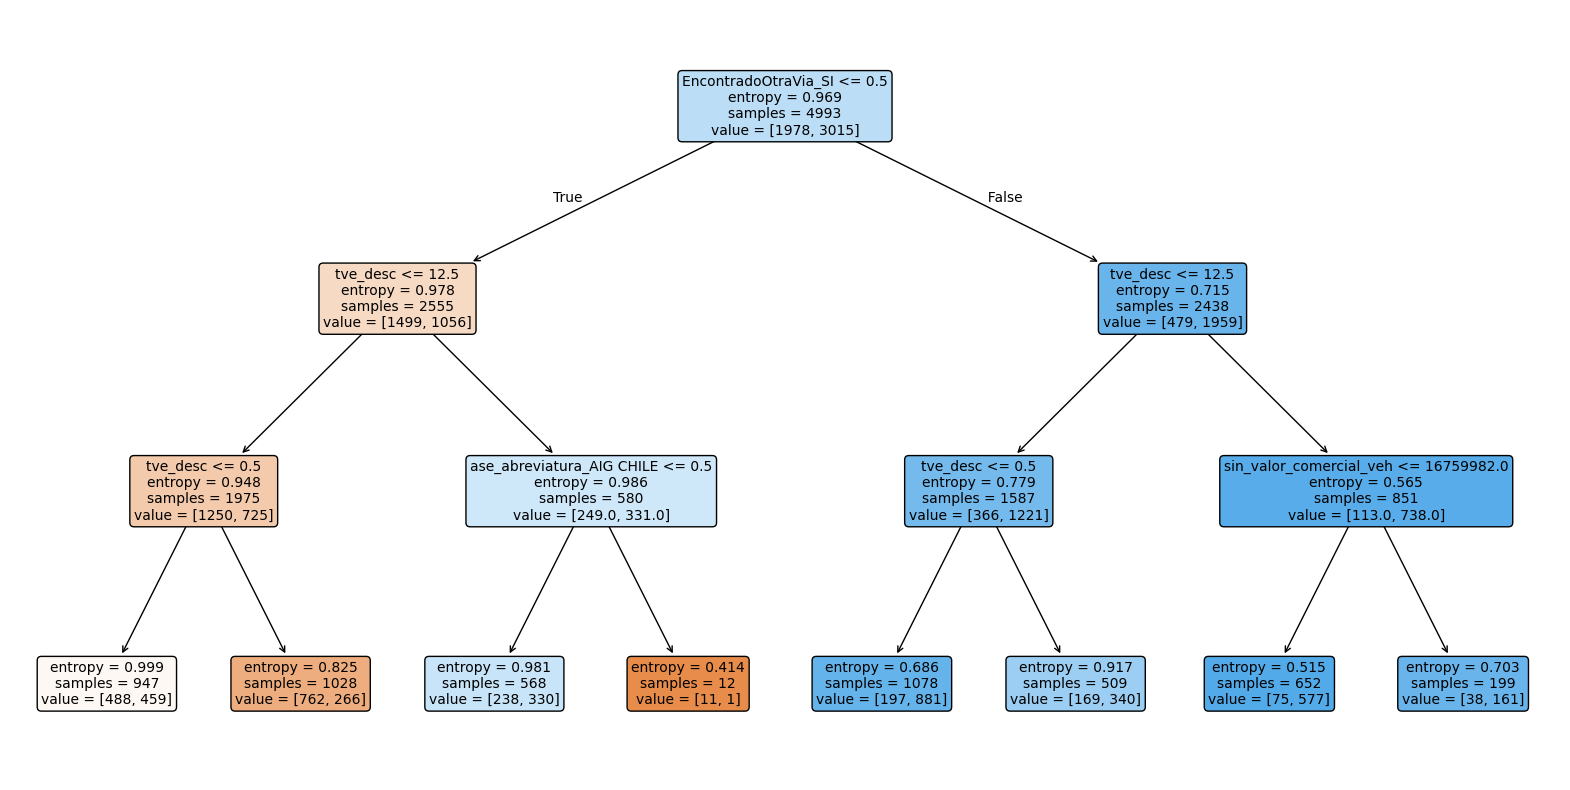

In [100]:
plt.figure(figsize=(20,10))
plot_tree(mejor_modelo.best_estimator_, 
          feature_names=features, 
          filled=True,                   
          rounded=True,                  
          fontsize=10)
plt.show()


In [102]:
y_pred_test = mejor_modelo.predict(x_test)
pd.DataFrame({"y_test": y_test, "y_pred_test": y_pred_test})

,y_test,y_pred_test
691,SEBV BUSCA,SEBV BUSCA
349,SEBV BUSCA,SEBV BUSCA
4697,SEBV ENCONTRO,SEBV BUSCA
5863,SEBV ENCONTRO,SEBV ENCONTRO
2627,SEBV BUSCA,SEBV BUSCA
...,...,...
325,SEBV BUSCA,SEBV BUSCA
26,SEBV BUSCA,SEBV BUSCA
3792,SEBV ENCONTRO,SEBV BUSCA
6365,SEBV ENCONTRO,SEBV BUSCA


Ahora evaluaremos ocupando las maetricas de accuracy, precision, recall y f1 score para evaluar el modelo en el conjunto de test.

In [87]:
print(classification_report(y_test, y_pred_test))
print(accuracy_score(y_test, y_pred_test))

                precision    recall  f1-score   support

    SEBV BUSCA       0.65      0.63      0.64       448
SEBV ENCONTRO        0.74      0.76      0.75       622

      accuracy                           0.70      1070
     macro avg       0.70      0.69      0.70      1070
  weighted avg       0.70      0.70      0.70      1070

0.7046728971962617


In [105]:
y_train_tree = mejor_modelo.predict(x_train)
print(classification_report(y_train, y_train_tree))
print(accuracy_score(y_train, y_train_tree))

                precision    recall  f1-score   support

    SEBV BUSCA       0.63      0.64      0.64      1978
SEBV ENCONTRO        0.76      0.76      0.76      3015

      accuracy                           0.71      4993
     macro avg       0.70      0.70      0.70      4993
  weighted avg       0.71      0.71      0.71      4993

0.7109953935509714


Los resultados obtenidos sugieren lo siguiente:
- `Precision`: `SEBV BUSCA` tiene una presicion de 0.65 y `SEBV ENCONTRO` tiene una precision de 0.74, lo que indica que el modelo es más preciso al predecir los vehiculos encontrados que los que se siguen buscando. La presicion en este contexto significa que de todos los vehiculos que el modelo dijo que se siguen buscando o fueron encontrados, cuantos de esos vehiculos realmente se siguen buscando o fueron encontrados.
- `Recall`: `SEBV BUSCA` tiene un recall de 0.63 y `SEBV ENCONTRO` tiene un recall de 0.76. En este contexto significa que de los vehiculos que realmente se siguen buscando, el modelo es capazar de ifentificar correctamente el 63% de ellos, mientras que de los vehiculos que realmente fueron encontrados, el modelo es capaz de identificar correctamente el 76% de ellos. 
- `F1 Score`: `SEBV BUSCA` tiene un f1 score de 0.64 y `SEBV ENCONTRO` tiene un f1 score de 0.75, lo que indica que el modelo tiene un mejor equilibrio entre precision y recall al predecir los vehiculos encontrados que los que se siguen buscando. 
- `Accuracy`: El modelo tiene una accuracy de 0.70, lo que indica que el modelo es capazar de predecir correctamente el 70% de los casos.

Tabla comparativa entre TEST Y ENTRENAMIENTO:

| Modelo | Accuracy | Precision SEBV BUSCA | Precision SEBV ENCONTRO | Recall SEBV BUSCA | Recall SEBV ENCONTRO | F1 Score SEBV BUSCA | F1 Score SEBV ENCONTRO |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Arbol de decision TEST | 0.70 | 0.65 | 0.74 | 0.63 | 0.76 | 0.64 | 0.75 |
| Arbol de decision TRAIN | 0.71 | 0.63 | 0.76 | 0.64 | 0.76 | 0.64 | 0.76 |



#### 2. Random Forest


Contiene el parametro `n_estimators` que representa la cantidad de arboles que se van a entrenar en el random forest. Buscaremos el mejor valor para este parametro utilizando grindsearch que veremos todas las combinaciones posibles de los parametros `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` y `criterion` para encontrar el mejor modelo.

Ocuparemos grindsearch para encontrar el mejor modelo, pero ojo, es mejor ocupar randomizedsearch para encontrar el mejor modelo, ya que grindsearch puede ser muy costoso computacionalmente, ya que evalua todas las combinaciones posibles de los hiperparametros, mientras que randomizedsearch evalua solo una muestra aleatoria de las combinaciones posibles de los hiperparametros, lo que puede ser mucho más eficiente computacionalmente, especialmente cuando se tienen muchos hiperparametros y muchas combinaciones posibles. Sin embargo, como en este caso, no se tarda demasiado tiempo en entrenar el modelo, se puede utilizar grindsearch para encontrar el mejor modelo.

In [90]:
modelo = RandomForestClassifier(random_state=42)

#Se ocuparan varios hiperparametros de la documentacion de DecisionTreeClassifier.

mejor_modelo_forest = GridSearchCV(modelo, {"n_estimators": [10, 50, 100, 200], "max_depth": [3, 5, 7, 10, 15, 20, None], "min_samples_split": [5, 10, 15, 20], "min_samples_leaf": [1, 2, 5, 10], "criterion": ["gini", "entropy"]}, cv=5, scoring="accuracy", n_jobs=-1)

mejor_modelo_forest.fit(x_train, y_train)

print("Mejores hiperparámetros:", mejor_modelo_forest.best_params_)


Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 100}


In [98]:
y_pred_val_forest = mejor_modelo_forest.predict(x_val)

pd.DataFrame({"y_val": y_val, "y_pred_val_forest": y_pred_val_forest})

,y_val,y_pred_val_forest
4420,SEBV ENCONTRO,SEBV ENCONTRO
3450,SEBV ENCONTRO,SEBV BUSCA
2488,SEBV BUSCA,SEBV ENCONTRO
1768,SEBV BUSCA,SEBV BUSCA
1886,SEBV BUSCA,SEBV BUSCA
...,...,...
3383,SEBV ENCONTRO,SEBV BUSCA
6732,SEBV ENCONTRO,SEBV ENCONTRO
1862,SEBV BUSCA,SEBV ENCONTRO
2687,SEBV BUSCA,SEBV BUSCA


In [97]:
y_pred_test_forest = mejor_modelo_forest.predict(x_test)
pd.DataFrame({"y_test": y_test, "y_pred_test_forest": y_pred_test_forest})

,y_test,y_pred_test_forest
691,SEBV BUSCA,SEBV BUSCA
349,SEBV BUSCA,SEBV BUSCA
4697,SEBV ENCONTRO,SEBV BUSCA
5863,SEBV ENCONTRO,SEBV ENCONTRO
2627,SEBV BUSCA,SEBV BUSCA
...,...,...
325,SEBV BUSCA,SEBV BUSCA
26,SEBV BUSCA,SEBV BUSCA
3792,SEBV ENCONTRO,SEBV BUSCA
6365,SEBV ENCONTRO,SEBV BUSCA


In [103]:
print(classification_report(y_test, y_pred_test_forest))
print(accuracy_score(y_test, y_pred_test_forest))

                precision    recall  f1-score   support

    SEBV BUSCA       0.64      0.60      0.62       448
SEBV ENCONTRO        0.73      0.76      0.74       622

      accuracy                           0.69      1070
     macro avg       0.69      0.68      0.68      1070
  weighted avg       0.69      0.69      0.69      1070

0.694392523364486


In [104]:
y_train_pred_forest = mejor_modelo_forest.predict(x_train)
print(classification_report(y_train, y_train_pred_forest))
print(accuracy_score(y_train, y_train_pred_forest))

                precision    recall  f1-score   support

    SEBV BUSCA       0.68      0.66      0.67      1978
SEBV ENCONTRO        0.78      0.80      0.79      3015

      accuracy                           0.74      4993
     macro avg       0.73      0.73      0.73      4993
  weighted avg       0.74      0.74      0.74      4993

0.7430402563589025


Se puede notar que el modelo de random forest es practicamente similar al modelo de arbol de decision, lo que puede indicar que el modelo de arbol de decision ya estaba captando la mayor parte de la complejidad del problema, por lo que el random forest no aporta una mejora significativa en el rendimiento del modelo. 

In [108]:
matriz_confusion = confusion_matrix(y_test, y_pred_test_forest)
print(matriz_confusion)

[[270 178]
 [149 473]]


Grafico de importancia de atributos (scikit-learn, s.f.)

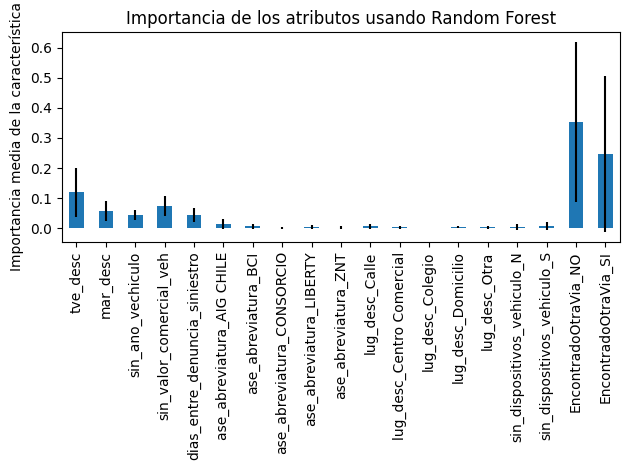

In [110]:
importancia = mejor_modelo_forest.best_estimator_.feature_importances_
std = np.std(
    [tree.feature_importances_ for tree in mejor_modelo_forest.best_estimator_.estimators_],
    axis=0
)
forest_importances = pd.Series(importancia, index=features)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr= std, ax=ax)
ax.set_title("Importancia de los atributos usando Random Forest")
ax.set_ylabel("Importancia media de la característica")
fig.tight_layout()
plt.show()

Se puede observar que las variables más importantes para el modelo son `tve_desc`, `sin_valor_comercial_veh` y `EncontradoOtraVia`, lo que indica que estas variables tienen un impacto significativo en la recuperación de los vehiculos robados. Pero notese que encontradoOtraVia es una variable que no se sabe exactamente que significa, por lo que es dificil de interpretar su importancia, y puede ser una variable que esta "prediciendo" el estado de busqueda del vehiculo, lo que puede ser un caso de data leakage, pero como se menciono anteriormente, aunque los vehiculos encontrados por otra via tienen una mayor probabilidad de ser encontrados, no es algo tan determinante como para que esta variable este prediciendo el estado de busqueda del vehiculo, por lo que se puede mantener esta variable para el análisis. Pero hay que tener ojo con esta variable, porques se puede observar que tiene una importancia muy alta, lo que puede indicar que esta variable esta prediciendo el estado de busqueda del vehiculo.

Tabla comparativa entre TEST Y ENTRENAMIENTO:

| Modelo | Accuracy | Precision SEBV BUSCA | Precision SEBV ENCONTRO | Recall SEBV BUSCA | Recall SEBV ENCONTRO | F1 Score SEBV BUSCA | F1 Score SEBV ENCONTRO |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Random Forest TEST | 0.70 | 0.64 | 0.73 | 0.60 | 0.76 | 0.62 | 0.74 |
| Random Forest TRAIN | 0.74 | 0.68 | 0.78 | 0.66 | 0.80 | 0.67 | 0.79 |


Randomforest se define como metodo ensamble porque combina varios arboles de desicion para mejorar la presicion y reducir el riesgo de sobreajuste, ya que al combinar varios arboles de desicion, se puede obtener un modelo más robusto y generalizable que un solo arbol de desicion.

#### 3. SVM

Se ocupara randomizedsearch para encontrar el mejor modelo, ya que grindsearch puede ser muy costoso computacionalmente, ya que evalua todas las combinaciones posibles de los hiperparametros y podria tardar demasiado tiempo en entrenar el modelo, especialmente cuando se tienen muchos hiperparametros y muchas combinaciones posibles. 
(scikit-learn, s.f.)

Los hiperparametros que se van a evaluar son `C`, `kernel` y `gamma`.
- `C`: Este hiperparámetro controla la penalización por errores de clasificación. Un valor más alto de C hace que el modelo intente clasificar correctamente todos los puntos de entrenamiento.

- `kernel`: Este hiperparámetro controla el tipo de kernel utilizado para transformar los datos. 

- `gamma`: Este hiperparámetro controla la influencia de un solo punto de entrenamiento. 



*`Uso De IA`*: Se le pregunto a la IA como reducir el tiempo de ejecucion del modelo, porque se demoraba más de 50 minutos y aun no terminaba y la ia sugerio normalizar. 

Les dejo el siguiente prompt: Necesito ocupar svm, pero se me demora mucho tiempo para buscar los hiperparametros, ocupando randomsearch, que tengo que hacer para que se demore menos?


Respuesta

```python
from sklearn.preprocessing import StandardScaler

# Normalizar
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# SVM con normalización
modelo_svm = SVC(random_state=42)

svm = {
    "C": [1, 10, 100],
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
    "gamma": ["scale", "auto"]
}

mejor_modelo_svm = RandomizedSearchCV(modelo_svm, hiperparametros_svm, n_iter=10, cv=5, scoring='accuracy', random_state=42)
mejor_modelo_svm.fit(x_train_scaled, y_train)


y_pred_svm = mejor_modelo_svm.predict(x_test_scaled)
print(classification_report(y_test, y_pred_svm))

```


StandardScaler transforma cada variable para que tenga media 0 y desviación estándar 1:

In [ ]:
modelo_svm = SVC(random_state=42)


normalizado = StandardScaler()
x_train_scaled = normalizado.fit_transform(x_train)
x_val_scaled = normalizado.transform(x_val)
x_test_scaled = normalizado.transform(x_test)

hiperparametros_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear" , 'poly', 'rbf', 'sigmoid'],
    "gamma": ["scale", "auto"],
}


mejor_modelo_svm = RandomizedSearchCV(modelo_svm, hiperparametros_svm,n_iter=5, cv=5, scoring="accuracy", n_jobs=-1, random_state=42)

mejor_modelo_svm.fit(x_train_scaled, y_train)

print("Mejores hiperparámetros:", mejor_modelo_svm.best_params_)

Mejores hiperparámetros: {'kernel': 'poly', 'gamma': 'auto', 'C': 100}


In [118]:
y_pred_val_svm = mejor_modelo_svm.predict(x_val_scaled)

pd.DataFrame({"y_val": y_val, "y_pred_val_svm": y_pred_val_svm})

,y_val,y_pred_val_svm
4420,SEBV ENCONTRO,SEBV ENCONTRO
3450,SEBV ENCONTRO,SEBV BUSCA
2488,SEBV BUSCA,SEBV BUSCA
1768,SEBV BUSCA,SEBV BUSCA
1886,SEBV BUSCA,SEBV BUSCA
...,...,...
3383,SEBV ENCONTRO,SEBV BUSCA
6732,SEBV ENCONTRO,SEBV ENCONTRO
1862,SEBV BUSCA,SEBV ENCONTRO
2687,SEBV BUSCA,SEBV BUSCA


In [119]:
y_pred_test_svm = mejor_modelo_svm.predict(x_test_scaled)

pd.DataFrame({"y_test": y_test, "y_pred_test_svm": y_pred_test_svm})
print(classification_report(y_test, y_pred_test_svm))
print(accuracy_score(y_test, y_pred_test_svm))

                precision    recall  f1-score   support

    SEBV BUSCA       0.65      0.57      0.61       448
SEBV ENCONTRO        0.71      0.78      0.75       622

      accuracy                           0.69      1070
     macro avg       0.68      0.67      0.68      1070
  weighted avg       0.69      0.69      0.69      1070

0.6906542056074766


In [120]:
y_pred_train_svm = mejor_modelo_svm.predict(x_train_scaled)

pd.DataFrame({"y_train": y_train, "y_pred_train_svm": y_pred_train_svm})
print(classification_report(y_train, y_pred_train_svm))
print(accuracy_score(y_train, y_pred_train_svm))

                precision    recall  f1-score   support

    SEBV BUSCA       0.67      0.62      0.65      1978
SEBV ENCONTRO        0.76      0.80      0.78      3015

      accuracy                           0.73      4993
     macro avg       0.72      0.71      0.71      4993
  weighted avg       0.73      0.73      0.73      4993

0.73022231123573


Tabla comparativa entre TEST Y ENTRENAMIENTO:

| Modelo | Accuracy | Precision SEBV BUSCA | Precision SEBV ENCONTRO | Recall SEBV BUSCA | Recall SEBV ENCONTRO | F1 Score SEBV BUSCA | F1 Score SEBV ENCONTRO |
| --- | --- | --- | --- | --- | --- | --- | --- |
| SVM TEST | 0.69 | 0.65 | 0.71 | 0.57 | 0.78 | 0.61 | 0.75 |
| SVM TRAIN | 0.73 | 0.67 | 0.76 | 0.62 | 0.80 | 0.65 | 0.78 |


#### Analisis de errores y diagnostico

Se puede observar que los modelos no tienen un rendimiento tan bueno al predecir los vehiculos que se siguen buscando, lo que puede indicar que el modelo tiene dificultades para identificar correctamente estos casos, lo que puede ser un problema importante, ya que el objetivo principal del modelo es identificar los vehiculos que se siguen buscando. Esto puede deberse a varias razones, como la falta de datos suficientes para entrenar el modelo en esta clase, o la presencia de ruido en los datos que dificulta la identificación de estos casos. 

Una hipotesis es la variable `EncontradoOtraVia` puede estar causando un caso de data leakage, ya que esta variable tiene una importancia muy alta en el modelo de random forest, lo que puede indicar que esta variable esta prediciendo el estado de busqueda del vehiculo, lo que puede ser un caso de data leakage.

En general, no hay modelo que tenga overfitting, ya que el rendimiento en el conjunto de entrenamiento y el conjunto de test es bastante similar, lo que indica que los modelos no están sobreajustados a los datos de entrenamiento. Sin embargo, es importante tener en cuenta que el rendimiento del modelo en el conjunto de test no es tan bueno como se esperaba.

En sintesis, los modelos tienen un rendimiento regular, pero no tan bueno como se esperaba.

# Referencias


GeeksforGeeks. (2025). Using pandas crosstab to create a bar plot. https://www.geeksforgeeks.org/python/using-pandas-crosstab-to-create-a-bar-plot/

pandas. (s.f.). DataFrame.where. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.where.html

scikit-learn. (s.f.). GridSearchCV. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

scikit-learn. (s.f.). DecisionTreeClassifier. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

scikit-learn. (s.f.). Feature importances with a forest of trees. https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

scikit-learn. (s.f.). SVC. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html